In [1]:
# Run only if libraries are missing
!pip install seaborn scikit-learn pandas matplotlib scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from pandas.plotting import parallel_coordinates
from scipy import stats

sns.set(style="whitegrid")


In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target
df['species'] = df['species'].map(
    dict(enumerate(iris.target_names))
)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


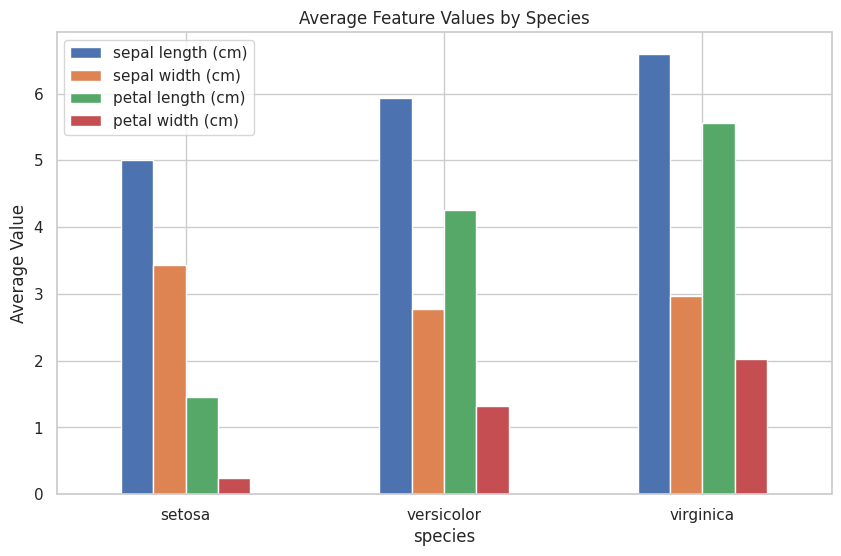

In [4]:
avg_values = df.groupby("species").mean()

avg_values.plot(kind='bar', figsize=(10,6))
plt.title("Average Feature Values by Species")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()


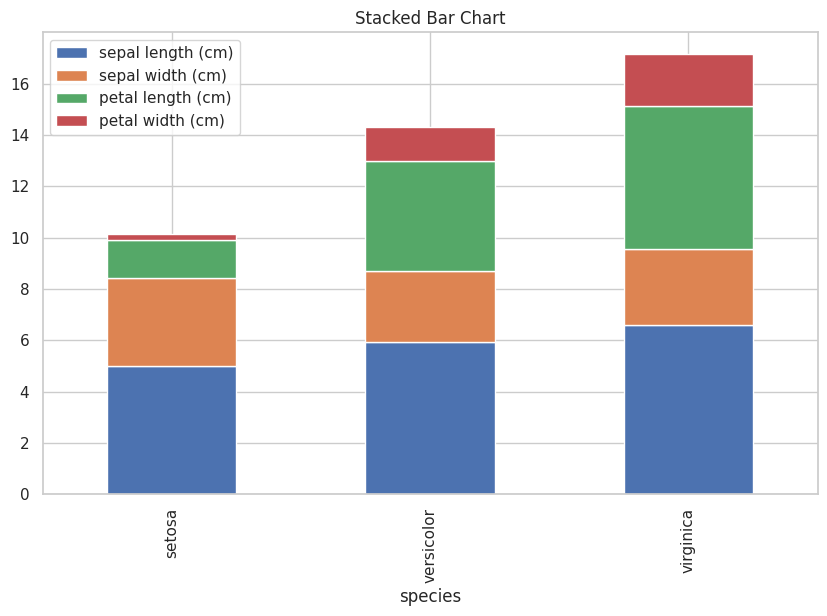

In [5]:
avg_values.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Stacked Bar Chart")
plt.show()


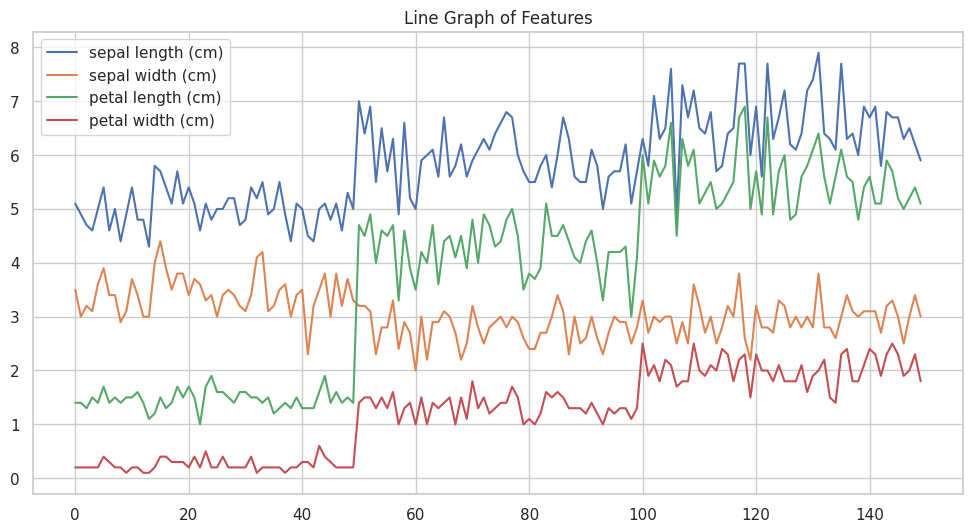

In [6]:
df.drop("species", axis=1).plot(
    kind='line',
    figsize=(12,6)
)

plt.title("Line Graph of Features")
plt.show()


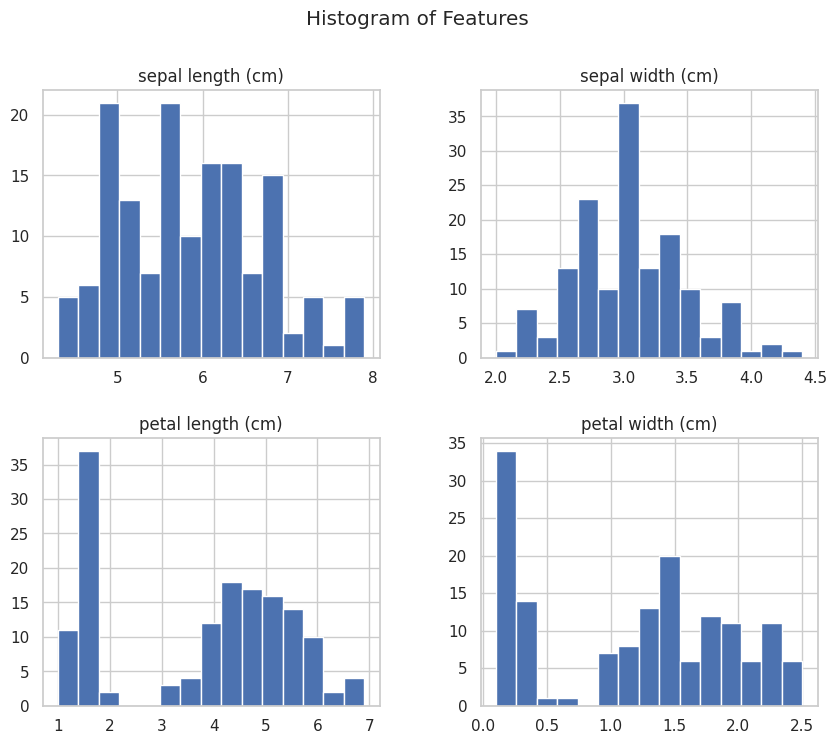

In [7]:
df.hist(figsize=(10,8), bins=15)
plt.suptitle("Histogram of Features")
plt.show()


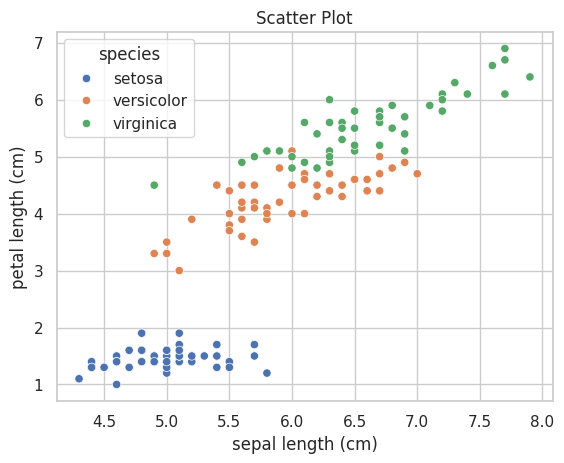

In [8]:
sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='petal length (cm)',
    hue='species'
)

plt.title("Scatter Plot")
plt.show()


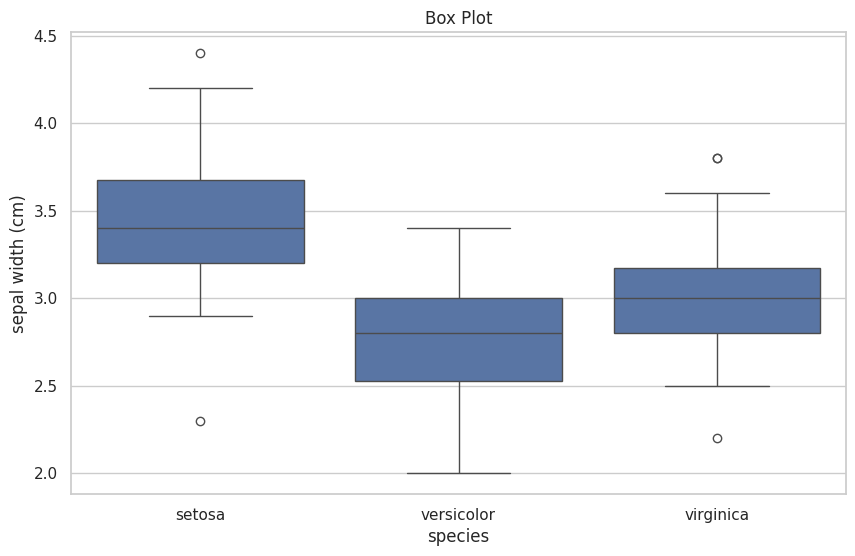

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='species', y='sepal width (cm)')
plt.title("Box Plot")
plt.show()


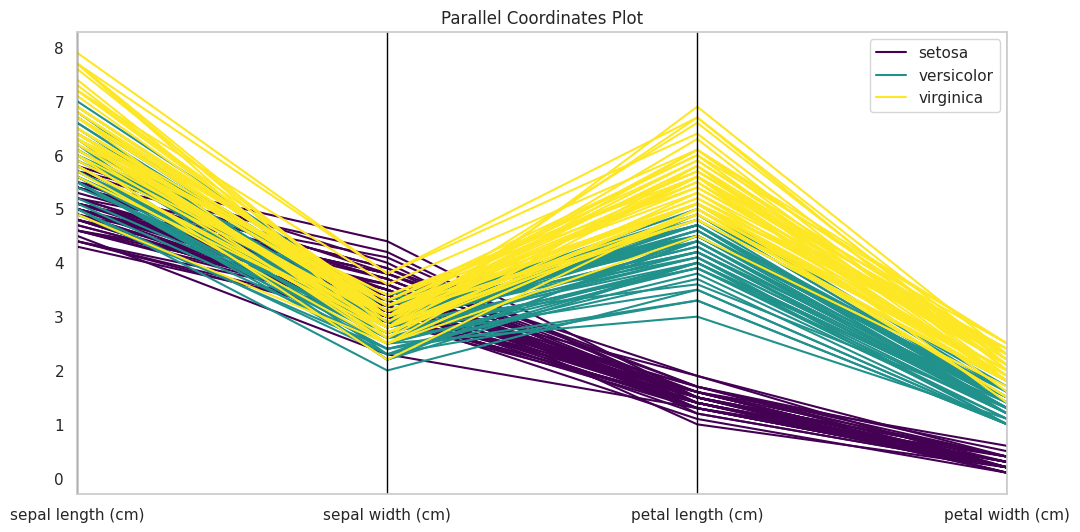

In [10]:
plt.figure(figsize=(12,6))
parallel_coordinates(
    df,
    'species',
    colormap='viridis'
)

plt.title("Parallel Coordinates Plot")
plt.show()


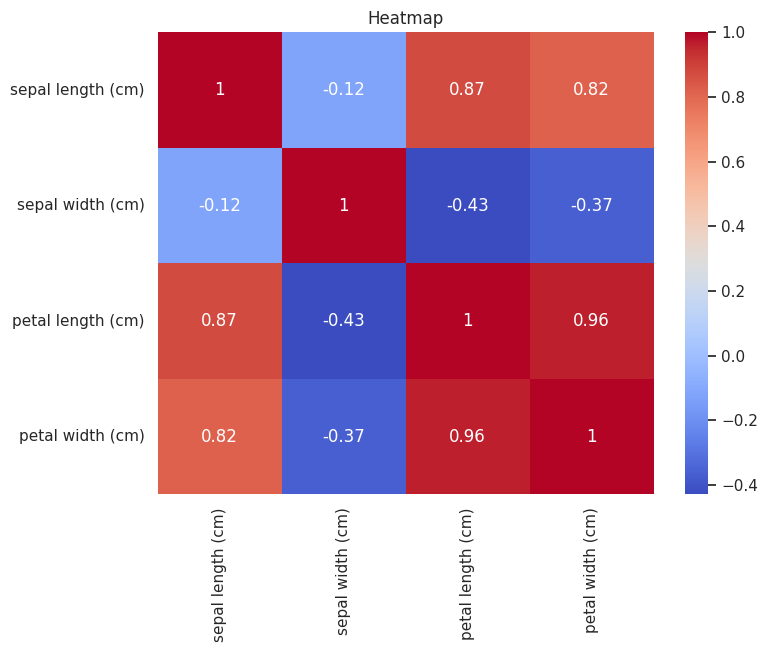

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.drop('species', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Heatmap")
plt.show()


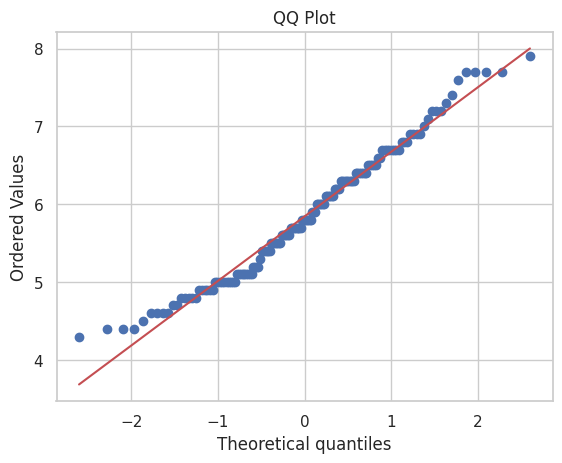

In [12]:
stats.probplot(
    df['sepal length (cm)'],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot")
plt.show()


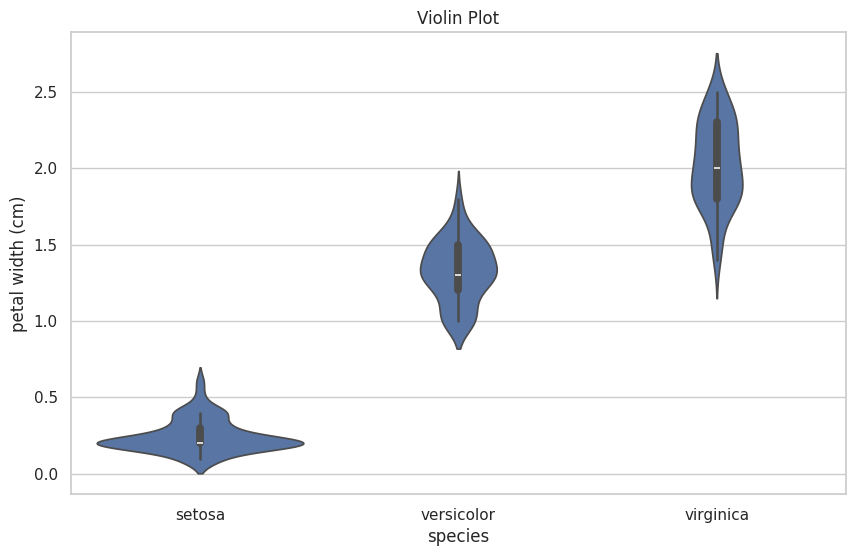

In [13]:
plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x='species',
    y='petal width (cm)'
)

plt.title("Violin Plot")
plt.show()


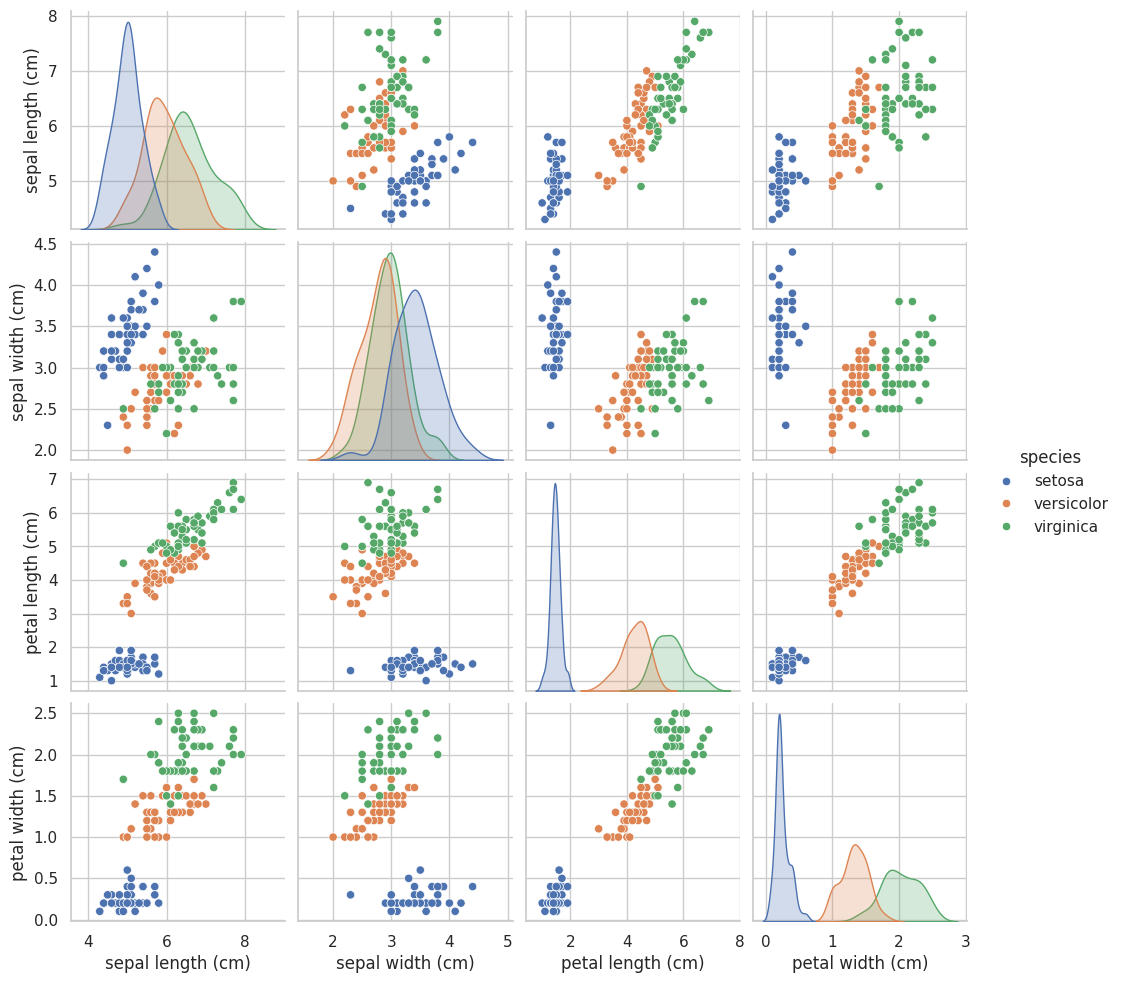

In [14]:
sns.pairplot(
    df,
    hue='species'
)

plt.show()


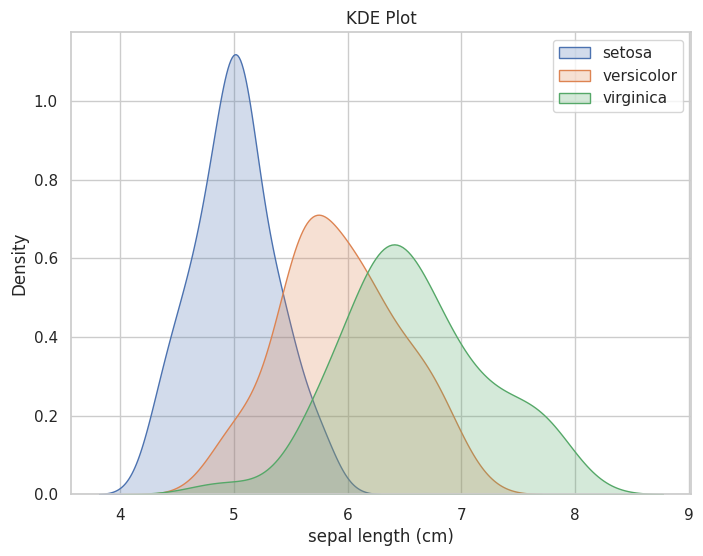

In [15]:
plt.figure(figsize=(8,6))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    sns.kdeplot(
        subset['sepal length (cm)'],
        label=species,
        fill=True
    )

plt.title("KDE Plot")
plt.legend()
plt.show()


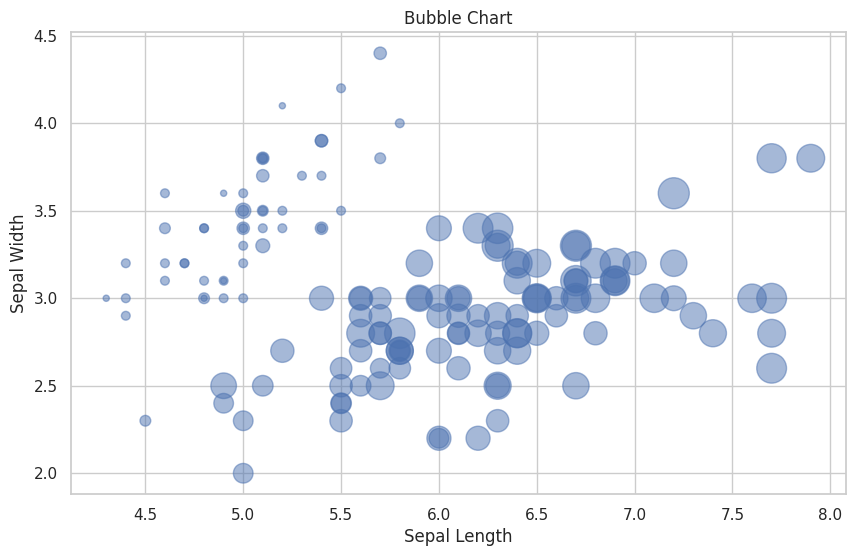

In [16]:
plt.figure(figsize=(10,6))

sizes = df['petal width (cm)'] * 200

plt.scatter(
    df['sepal length (cm)'],
    df['sepal width (cm)'],
    s=sizes,
    alpha=0.5
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Bubble Chart")

plt.show()
